In [107]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [134]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from copy import deepcopy
from pathlib import Path
from openquake.hazardlib.imt import PGA, SA, RSD595, AvgSA, IMT

from pickagm.distributions import (
    ensemble_ecdfs, 
    ensemble_quantiles,
    ensemble_ks_test,
    ensemble_r_score,
    ensemble_ks_bounds
    )

from pickagm.selection import (
    preselection,
    scale_records_in_db,
    filter_on_sf
    )

from phd_project.config import config
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    ESHM20SiteRupCtxBuilder,
    create_gmm_map,
    create_corr_model_map,
    get_m_bounds,
    get_d_bounds,
    get_vs30_bounds,
    get_disagg_percentiles,
    d_bounds_tarbali_and_bradley_2016,
    m_bounds_tarbali_and_bradley_2016,
    get_imtl_from_disaggstats,
    get_ground_motion_ensembles_for_sites,
    adjust_ensemble_distributions,
    greedy_optimise_ensemble,
    sse_point_stats,
    weighted_ks_statistic,
    weighted_ks_statistic_and_failing_im_penalty,
    total_ks_statistic,
    total_ks_statistic_and_failing_im_penalty
)
import phd_project.scripts.WP1_ground_motion_set.manage_flatfiles as mf
from phd_project.plotting import custom_log_formatter, plot_im_ecdf_vs_target

cfg = config.load_config()

In [109]:
# load the site file
sites = pd.read_csv(cfg["hazard_models"]["eshm20_AvgSA_site_model_all"])

# load the flatfiles
flatfile_folder = cfg["proc_data"]["corr_model"] / "reverse" / "flatfiles"
flatfiles = {}
for f in [f for f in os.listdir(flatfile_folder) if f.endswith(".csv")]:
    tag = f.split("_")[0]
    flatfiles[tag] = pd.read_csv(flatfile_folder / f, delimiter=";", index_col=0, low_memory=False)

flatfiles["volcanic"] = pd.read_csv(cfg["raw_data"]["gm_flatfiles"] / "volcanic_lanzanoluzi_flatfile.csv", 
                                    delimiter=";", index_col=0)

# load the preprocessed gm database
gm_database = pd.read_csv(cfg["proc_data"]["gm_database"], sep=",", low_memory=False, header=[0, 1])

# load disaggregation data
fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"
with open(fp, "rb") as f:
    disagg_data = pickle.load(f)

# create the average depth map for each TRT
average_depths = {
    "Craton": flatfiles["asc"]["ev_depth_km"].mean(),
    "Non-Subduction Deep": flatfiles["vran"]["ev_depth_km"].mean(),
    "Shallow Default": flatfiles["asc"]["ev_depth_km"].mean(),
    "Subduction Inslab": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Subduction Interface": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Volcanic": flatfiles["volcanic"]["ev_depth_km"].mean(),
}

# the map of what sim trts are allowed to match with what record trts
OK_TRT_MATCHES = {
    "Craton": ["Shallow Default"],
    "Non-Subduction Deep": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Shallow Default": ["Shallow Default"],
    "Subduction Inslab": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Subduction Interface": ["Subduction Interface"],
    "Volcanic": ["Shallow Default"],
}

occurence = True    # the record selection should be performed based on occurence


# set some parameters for the selection
t_lower = 0.025     # lower SA period considered in selection
t_upper = 6         # upper SA period considered in selection
n_periods = 20      # number of periods to consider in selection

conditioning_imt: IMT = AvgSA([0,6])                      
nonSA_imts: list[IMT] = [AvgSA([0,6]), RSD595(), PGA()] 
sa_periods = np.round(np.geomspace(t_lower, t_upper, num=n_periods), 3)
SA_imts: list[IMT] = [SA(period) for period in sa_periods]
selection_imts: list[IMT] = nonSA_imts[1:] + SA_imts    # not AvgSA but the others (PGA and RSD595)
nonSA_imt_strs: list[str] = [im.string for im in nonSA_imts] # strings match the correlation matrix

# weights of the IMs
weight_rsd595 = 0.1
n_other_ims = len([imt for imt in selection_imts if imt.name == "SA" or imt.name == "PGA"])
imt_weights = np.array([(1-weight_rsd595) / n_other_ims if imt.name != "RSD595" 
                        else weight_rsd595 for imt in selection_imts])
imt_weights /= imt_weights.sum()

# some other things
disagg_type = "TRT_Mag_Dist_Eps"
percentiles = [0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.95]     # percentiles of the gcim distribution to return  
assumed_rake = -90                                # assumed rake for RSD595 calculation

# filter the gm_database so that only the selection and conditioning ims are present
gm_db = gm_database.copy()
updated_ims = mf.filter_gm_database_on_imts(
    gm_db["ims"], selection_imts + [conditioning_imt])
updated_ims.columns = pd.MultiIndex.from_product([['ims'], updated_ims.columns])
gm_db = pd.concat([gm_db.drop('ims', axis=1, level=0), updated_ims], axis=1)

# Create the GMM Map for AvgSA by reading the logic tree
AvgSA_06_lt_fp = cfg["hazard_models"]["eshm20_AvgSA"] / "gmpe_logic_tree_AvgSA_0to6_median_branch.xml"
gmm_map = create_gmm_map(AvgSA_06_lt_fp)

# get the correlation model map
corr_map = create_corr_model_map(nonSA_imt_strs, sa_periods)

# organise the disagg data
site_poe_disaggs = {}
for (s, r) in disagg_data.keys():
    for site in disagg_data[(s,r)].keys():
        for poe in disagg_data[(s,r)][site][conditioning_imt.name].keys():
            site_poe_disaggs[(site, poe)] = disagg_data[(s,r)][site][conditioning_imt.name][poe]
site_poes = sorted(list(site_poe_disaggs.keys()), key=lambda x: x[0])

fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle"
with open(fp, "rb") as f:
    disagg_stats= pickle.load(f)

# load the gcim distribution data
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_06_rake{int(assumed_rake)}.pickle"
with open(gcim_dist_fp, "rb") as file:
    gcim_dists = pickle.load(file)

# load the preliminary record selection data
preliminary_selection_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_prelim_selection_rake{int(assumed_rake)}.pickle"

with open(preliminary_selection_fp, "rb") as file:
    preliminary_ensembles = pickle.load(file)

preliminary_ensembles = {k: v for k, v in sorted(preliminary_ensembles.items())}

# load the optimised ensemble data
optimised_selection_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_optimised_selection_rake{int(assumed_rake)}.pickle"
with open(optimised_selection_fp, "rb") as file:
    optimised_ensembles = pickle.load(file)

optimised_ensembles = {k: v for k, v in sorted(optimised_ensembles.items())}

In [179]:
basic_selection_ctx = {
    "n_ensembles": 20,
    "n_samples": 30,
    "conditioning_imt": conditioning_imt ,
    "disagg_imt": conditioning_imt.name , # this only works for AvgSA. otherwise used .string 
    "selection_imts": selection_imts ,
    "imt_weights": imt_weights ,
    "sites": sites ,
    "ctx_builder": ESHM20SiteRupCtxBuilder ,
    "ctx_builder_params": ["average_depths", "assumed_rake"] ,
    "average_depths": average_depths ,
    "assumed_rake": assumed_rake ,
    "gmm_map": gmm_map ,
    "corr_map": corr_map ,
    "m_bound_model": "tarbali_and_bradley_2016" ,
    "d_bound_model": "tarbali_and_bradley_2016" ,
    "vs30_bound_model": "tarbali_and_bradley_2016" ,
    "sf_bounds": (0.05, 20),
    "usable_T": t_upper ,
    "max_n_recs": 5 ,
    "p_value": 0.05 ,
    "ok_trt_matches": OK_TRT_MATCHES ,
    "occurence": True ,
}

rng_seed = 4

In [111]:
not_passing = [
    (30, np.float64(0.0001)),
    (35, np.float64(0.000201)),
    (35, np.float64(0.0001)),
    (36, np.float64(0.0001)),
    (37, np.float64(0.0001)),
    (39, np.float64(0.000201)),
    (39, np.float64(0.0001)),
    (41, np.float64(0.000404)),
    (41, np.float64(0.0001)),
    (43, np.float64(0.000201)),
    (43, np.float64(0.0001)),
    (44, np.float64(0.000201)),
    (44, np.float64(0.0001)),
    (46, np.float64(0.000404)),
    (46, np.float64(0.0001)),
    (51, np.float64(0.000201)),
    (51, np.float64(0.0001)),
    (52, np.float64(0.000201)),
    (53, np.float64(0.0001)),
    (4, np.float64(0.000201)),
    (7, np.float64(0.0001)),
    (10, np.float64(0.0001)),
    (21, np.float64(0.000201)),
    (21, np.float64(0.0001)),
    (23, np.float64(0.000201)),
    (23, np.float64(0.0001))
    ]

not_passing.sort()

In [183]:
# count failing IMS in the optmised ensembles
failing_ims = []
for site_poe, e in optimised_ensembles.items():
    if site_poe in not_passing:
        ims = e["ks_failed_ims"]
        failing_ims.append(ims)
        print(f"{site_poe[0]:>3}{site_poe[1]:>10.6f}  {ims}")

# failing ensembles
failing_ens_nums = []
for ii, (site, poe) in enumerate(preliminary_ensembles.keys()):
    if (site, poe) in not_passing:
        failing_ens_nums.append(ii)



  4  0.000201  ['SA(6.0)']
  7  0.000100  ['RSD595']
 10  0.000100  ['RSD595']
 21  0.000100  ['RSD595']
 21  0.000201  ['RSD595']
 23  0.000100  ['SA(6.0)']
 23  0.000201  ['SA(6.0)']
 30  0.000100  ['RSD595']
 35  0.000100  ['RSD595']
 35  0.000201  ['RSD595']
 36  0.000100  ['RSD595']
 37  0.000100  ['RSD595']
 39  0.000100  ['RSD595']
 39  0.000201  ['RSD595']
 41  0.000100  ['RSD595']
 41  0.000404  ['RSD595']
 43  0.000100  ['RSD595']
 43  0.000201  ['RSD595']
 44  0.000100  ['RSD595']
 44  0.000201  ['RSD595']
 46  0.000100  ['RSD595']
 46  0.000404  ['RSD595']
 51  0.000100  ['RSD595']
 51  0.000201  ['RSD595']
 52  0.000201  ['SA(6.0)']
 53  0.000100  ['RSD595']


In [162]:
def joint_availability(filtered_gm_database, target_cdfs, ims):
    """
    Checks if records exist that simultaneously satisfy the 10th-90th 
    percentile of the 'failing' IMs.
    
    im_indices: list of indices for problematic IMs (e.g., [21, 22])
    """
    results = {}

    # Define the 'Success Zone' as the 10th to 90th percentile of target
    # You can tighten this to 25th-75th for a stricter test
    for im in ims:
        target_imls = target_cdfs[im][:, 0]
        target_probs = target_cdfs[im][:, 1]
        
        # Get physical values for the 10th and 90th percentile of the target
        val_low = np.interp(0.10, target_probs, target_imls)
        val_high = np.interp(0.90, target_probs, target_imls)
        
        # Logical mask for records in the pool that fit this IM individually
        in_range = (filtered_gm_database.loc[:, ("ims_scaled", im)] >= val_low) & \
                   (filtered_gm_database.loc[:, ("ims_scaled", im)] <= val_high)
        results[im] = in_range

    # Find the intersection: records that satisfy ALL problematic IMs
    joint_mask = np.logical_and.reduce(list(results.values()))
    usable_count = np.sum(joint_mask)

    return usable_count, joint_mask

In [184]:
# get the filtered database for every site and poe
site_selection_ctx = basic_selection_ctx.copy()
unique_trts = gm_db[("metadata", "trt")].unique()

filtered_dbs = {}
e_trt_breakdowns = {}
trt_db_rec_counts = {}
db_percentiles = {}
availabilities = {}

for (site, poe), e in optimised_ensembles.items():
    site_params = sites.loc[site,:].to_dict()
    site_selection_ctx["site_params"] = site_params
    
    mag_bounds = get_m_bounds(site_poe_disaggs[(site, poe)], occurence=True, model=site_selection_ctx["m_bound_model"])
    dist_bounds = get_d_bounds(site_poe_disaggs[(site, poe)], occurence=True, model=site_selection_ctx["d_bound_model"])
    vs30_bounds = get_vs30_bounds(site_selection_ctx["site_params"]["vs30"], model=site_selection_ctx["vs30_bound_model"])
    
    conditioning_iml = get_imtl_from_disaggstats(
        disagg_stats, site, conditioning_imt.name, poe)

    filtered_gm_db = preselection(gm_db, mag_bounds, dist_bounds, vs30_bounds, site_selection_ctx["usable_T"])
    filtered_gm_db = scale_records_in_db(filtered_gm_db, conditioning_imt, conditioning_iml)
    filtered_gm_db = filter_on_sf(filtered_gm_db, site_selection_ctx["sf_bounds"])
    filtered_dbs[(site, poe)] = filtered_gm_db
    
    # calculate the number of records of each TRT type available
    trt_n_records = filtered_gm_db.groupby(("metadata", "trt")).size()
    trt_n_records["total"] = len(filtered_gm_db)
    ensemble_trt_counts = e["recs"].groupby(("metadata", "trt")).size()
    ensemble_trt_propos = ensemble_trt_counts / sum(ensemble_trt_counts)
    e_trt_breakdown = pd.concat([ensemble_trt_counts, ensemble_trt_propos], axis=1)
    e_trt_breakdown.columns = ["count", "frac"]

    e_trt_breakdowns[(site, poe)] = e_trt_breakdown
    trt_db_rec_counts[(site, poe)] = trt_n_records
    
    # calculate the 0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.95 percentile values
    percentiles = [0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.95]
    prct_df = filtered_gm_db["ims_scaled"].quantile(q=percentiles, axis=0).T
    prct_df.columns = percentiles
    db_percentiles[(site, poe)] = prct_df

    # find the records that simultaneously satisfy the 10th-90th percentile of 
    # RSD595 and SA(6.0) for shallow default dominated sites
    target_cdfs = gcim_dists[(site, poe)]["cdfs"]
    shallow_default_db = filtered_gm_db[filtered_gm_db[("metadata", "trt")] == "Shallow Default"]
    count, mask = joint_availability(shallow_default_db, target_cdfs, ["RSD595", "SA(6.0)"])
    availabilities[(site, poe)] = {
        "count": count,
        "frac": count / len(shallow_default_db)}

    # for each IM in the database
    # compare these to the values from the target spectrum
    if (site, poe) in not_passing:
        ims = e["ks_failed_ims"] + ["SA(1.063)", "RSD595", "SA(6.0)"]
        ims = list(set(ims))
        for im in ims:
            ks_bounds = e["ks_bounds"][im]
            fig, ax = plt.subplots()
            ax = plot_im_ecdf_vs_target(ax, e["ecdfs"][im], ks_bounds)
            ax.plot(prct_df.loc[im, :], prct_df.columns, marker="o", color="r", ls="none")
            ax.set_title(f"{site} - {poe} - {im}")
            ax.set_xlabel(f"{im}")
            ax.set_ylabel(f"CDF")
            folder = Path(rf"C:\Users\clemettn\Documents\figs\target_cdf_vs_database_cdf_{im}")
            folder.mkdir(parents=True, exist_ok=True)
            fig.savefig(folder / rf"site_{site}__poe{str(poe).replace(".", "pt")}__{im}.jpeg")
            plt.close(fig)

    # # look at the M and D distributions of the sims from the preliminary results
    # # how do these compare with?
combined_e_trt_breakdowns = pd.concat(e_trt_breakdowns)
combined_e_trt_breakdowns = combined_e_trt_breakdowns.unstack()
combined_e_trt_breakdowns = combined_e_trt_breakdowns.fillna(0)

combined_db_trt_counts = pd.concat(trt_db_rec_counts)
combined_db_trt_counts = combined_db_trt_counts.unstack()
combined_db_trt_counts = combined_db_trt_counts.fillna(0)

availabilities = pd.DataFrame.from_dict(availabilities, orient="index").sort_index()

In [177]:
# get the trt proportions from the disaggregation
disagg_trts_propos = {}
for (site, poe), disagg_dist in site_poe_disaggs.items():
    disagg_trts_propos[(site, poe)] = np.round(disagg_dist.groupby("TRT")["P(m|X=x)"].sum(), 3)

disagg_trts_propos = pd.concat(disagg_trts_propos)
disagg_trts_propos = disagg_trts_propos.unstack()
disagg_trts_propos = disagg_trts_propos.fillna(0)

# get the quantiles of the distance distribution for each disaggregation
disagg_d_quantiles = {}
for (site, poe), disagg_dist in site_poe_disaggs.items():
    disagg_d_quantiles[(site, poe)] = get_disagg_percentiles(disagg_dist, "Dist", "P(m|X=x)", targets=[0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.95])

disagg_d_quantiles = pd.concat([pd.DataFrame(qs, index=[site_poe]) for site_poe, qs in disagg_d_quantiles.items()], axis=0)
disagg_d_quantiles = disagg_d_quantiles.sort_index()

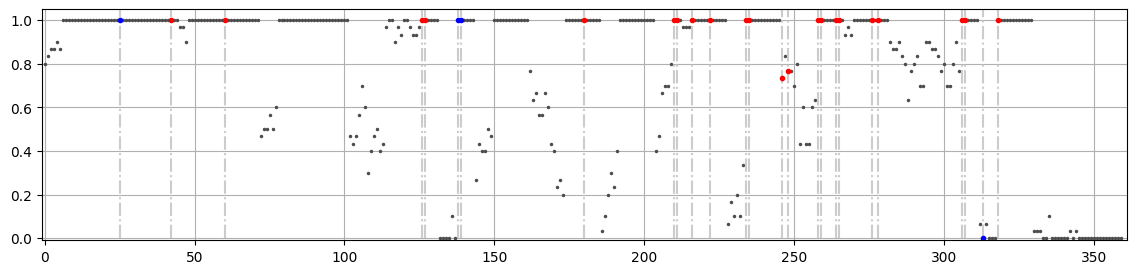

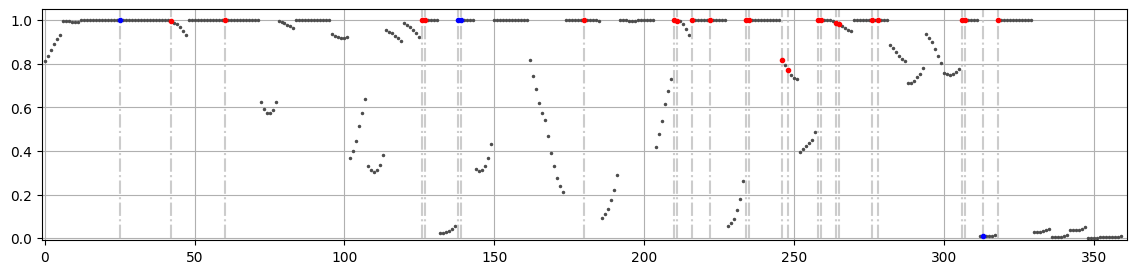

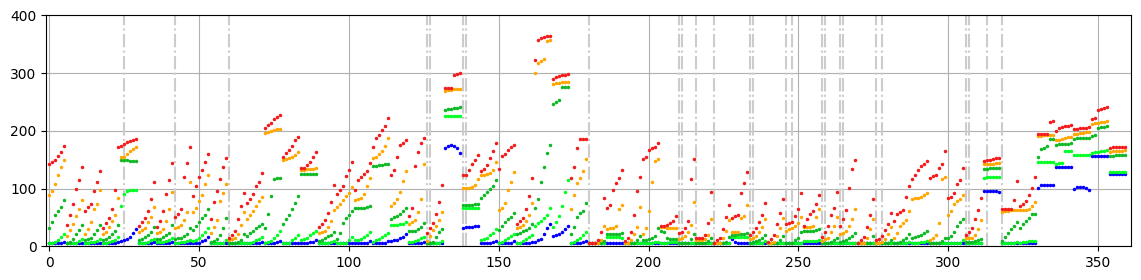

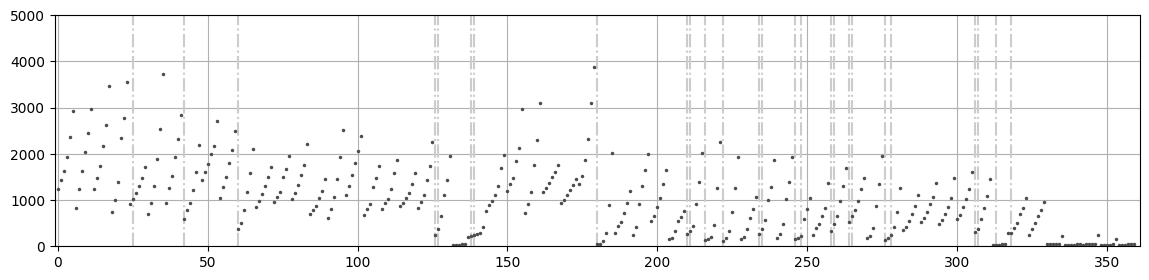

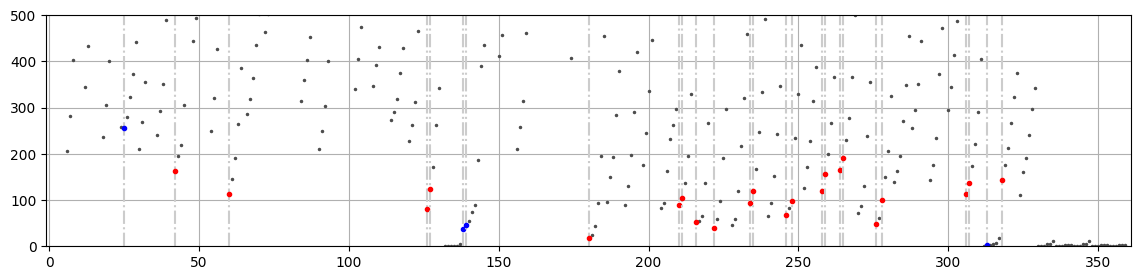

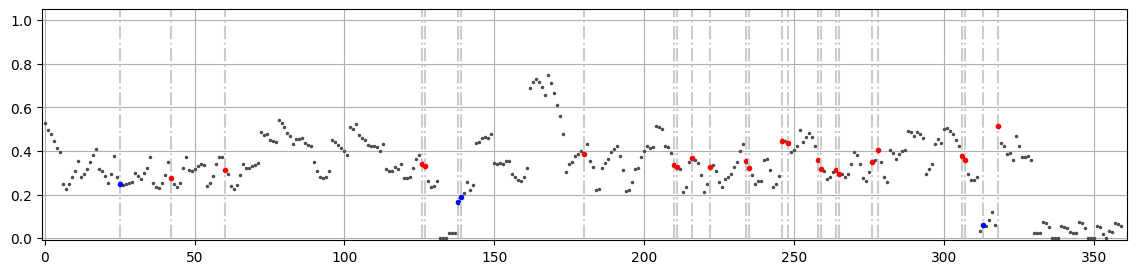

In [181]:
################################################################################
# the trt distributions from the record ensembles
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(combined_e_trt_breakdowns[("frac", "Shallow Default")].values, ls="none", marker=".", markersize=3, color="0.3")
for (site, poe), ii in zip(not_passing, failing_ens_nums):
    ax.vlines(ii, 0, 1.1, color="0.8", ls="-.")

    e = optimised_ensembles[(site, poe)]
    im = e["ks_failed_ims"][0]
    if im == "RSD595":
        ax.plot(ii, combined_e_trt_breakdowns.loc[(site, poe), ("frac", "Shallow Default")], color="r", marker=".")
    elif im == "SA(6.0)":
        ax.plot(ii, combined_e_trt_breakdowns.loc[(site, poe), ("frac", "Shallow Default")], color="b", marker=".")
    else:
        ax.plot(ii, combined_e_trt_breakdowns.loc[(site, poe), ("frac", "Shallow Default")], color="g", marker=".")

ax.set_xlim(-1, 361)
ax.set_ylim(-0.01, 1.05)
ax.grid(True)

################################################################################
# the trt distributions from the disaggregation
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(disagg_trts_propos["Shallow Default"].values, ls="none", marker=".", markersize=3, color="0.3")
for (site, poe), ii in zip(not_passing, failing_ens_nums):
    ax.vlines(ii, 0, 1.1, color="0.8", ls="-.")

    e = optimised_ensembles[(site, poe)]
    im = e["ks_failed_ims"][0]
    if im == "RSD595":
        ax.plot(ii, disagg_trts_propos.loc[(site, poe), "Shallow Default"], color="r", marker=".")
    elif im == "SA(6.0)":
        ax.plot(ii, disagg_trts_propos.loc[(site, poe), "Shallow Default"], color="b", marker=".")
    else:
        ax.plot(ii, disagg_trts_propos.loc[(site, poe), "Shallow Default"], color="g", marker=".")

ax.set_xlim(-1, 361)
ax.set_ylim(-0.01, 1.05)
ax.grid(True)

################################################################################
# the distance distributions from the disaggregation
fig, ax = plt.subplots(figsize=(14, 3))
for (site, poe), ii in zip(not_passing, failing_ens_nums):
    ax.vlines(ii, 0, 400, color="0.8", ls="-.")

ax.plot(disagg_d_quantiles[0.05].values, ls="none", marker=".", markersize=3, color="#0400FF")
ax.plot(disagg_d_quantiles[0.16].values, ls="none", marker=".", markersize=3, color="#00FF22")
ax.plot(disagg_d_quantiles[0.5].values, ls="none", marker=".", markersize=3, color="#0EB925")
ax.plot(disagg_d_quantiles[0.84].values, ls="none", marker=".", markersize=3, color="#FFA600")
ax.plot(disagg_d_quantiles[0.95].values, ls="none", marker=".", markersize=3, color="#F31B1B")

ax.set_xlim(-1, 361)
ax.set_ylim(-0.01, 400)
ax.grid(True)

################################################################################
fig, ax = plt.subplots(figsize=(14, 3))
for (site, poe), ii in zip(not_passing, failing_ens_nums):
    ax.vlines(ii, 0, 10000, color="0.8", ls="-.")
ax.plot(combined_db_trt_counts["Shallow Default"].values, ls="none", marker=".", markersize=3, color="0.3")
# ax.plot(combined_db_trt_counts["Non-Subduction Deep"].values, ls="none", marker="^", markersize=3, color="0.3")
# ax.plot(combined_db_trt_counts["Subduction Inslab"].values, ls="none", marker="s", markersize=3, color="0.3")
# ax.plot(combined_db_trt_counts["Subduction Interface"].values, ls="none", marker="d", markersize=3, color="0.3")

ax.set_xlim(-1, 361)
ax.set_ylim(0, 5000)
ax.grid(True)

################################################################################
# Number of Shallow default records jointly satisfying RSD595 and SA(6.0) 
# after distance, mag, vs30 and scale filtering
fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(availabilities["count"].values, ls="none", marker=".", markersize=3, color="0.3")
for (site, poe), ii in zip(not_passing, failing_ens_nums):
    ax.vlines(ii, 0, 1750, color="0.8", ls="-.")

    e = optimised_ensembles[(site, poe)]
    im = e["ks_failed_ims"][0]
    if im == "RSD595":
        ax.plot(ii, availabilities.loc[(site, poe), "count"], color="r", marker=".")
    elif im == "SA(6.0)":
        ax.plot(ii, availabilities.loc[(site, poe), "count"], color="b", marker=".")
    else:
        ax.plot(ii, availabilities.loc[(site, poe), "count"], color="g", marker=".")


ax.set_xlim(-1, 361)
ax.set_ylim(-0.01, 500)
ax.grid(True)

################################################################################
# Number of records jointly satisfying RSD595 and SA(6.0) as a proportion of the
# total available Shallow default records after distance, mag, vs30 and scale filtering
fig, ax = plt.subplots(figsize=(14, 3))

ax.plot(availabilities["frac"].values, ls="none", marker=".", markersize=3, color="0.3")
for (site, poe), ii in zip(not_passing, failing_ens_nums):
    ax.vlines(ii, 0, 1.1, color="0.8", ls="-.")

    e = optimised_ensembles[(site, poe)]
    im = e["ks_failed_ims"][0]
    if im == "RSD595":
        ax.plot(ii, availabilities.loc[(site, poe), "frac"], color="r", marker=".")
    elif im == "SA(6.0)":
        ax.plot(ii, availabilities.loc[(site, poe), "frac"], color="b", marker=".")
    else:
        ax.plot(ii, availabilities.loc[(site, poe), "frac"], color="g", marker=".")


ax.set_xlim(-1, 361)
ax.set_ylim(-0.01, 1.05)
ax.grid(True)

In [97]:
combined_db_trt_counts

('metadata', 'trt')  Non-Subduction Deep  Shallow Default  Subduction Inslab  \
0  0.000100                         11.0           1513.0             2339.0   
   0.000201                         18.0           1681.0             2639.0   
   0.000404                         25.0           1902.0             3075.0   
   0.001000                         48.0           2172.0             3793.0   
   0.002103                         70.0           2696.0             4331.0   
...                                  ...              ...                ...   
59 0.000201                          0.0             37.0              657.0   
   0.000404                          0.0             37.0              859.0   
   0.001000                          0.0             47.0             1022.0   
   0.002103                          0.0             50.0             1111.0   
   0.004988                          0.0             56.0             1430.0   

('metadata', 'trt')  Subduction Interface    total  
0  0.000100                        2821.0   6684.0  
   0.000201                        3200.0   7538.0  
   0.000404                        3748.0   8750.0  
   0.001000                        4600.0  10613.0  
   0.002103                        5259.0  12356.0  
...                                   ...      ...  
59 0.000201                        1379.0   2073.0  
   0.000404                        1502.0   2398.0  
   0.001000                        1860.0   2929.0  
   0.002103                        2182.0   3343.0  
   0.004988                        2595.0   4081.0  

[360 rows x 5 columns]

In [121]:
combined_e_trt_breakdowns.loc[(52, 0.000201), :]

       (metadata, trt)     
count  Shallow Default          0.0
       Subduction Inslab       30.0
       Subduction Interface     0.0
frac   Shallow Default          0.0
       Subduction Inslab        1.0
       Subduction Interface     0.0
Name: (52, 0.000201), dtype: float64

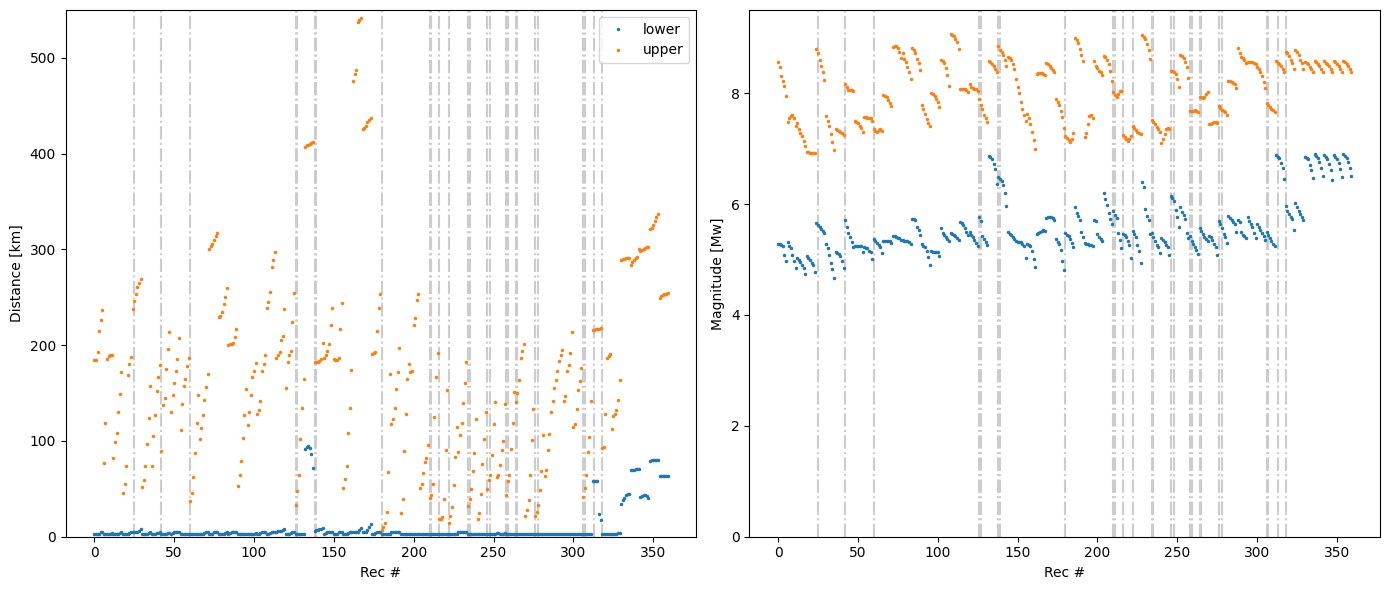

In [123]:
lower_d = []
upper_d = []
lower_m = []
upper_m = []

failing_rec_nums = []
for ii, (site, poe) in enumerate(optimised_ensembles.keys()):
    d_bounds = d_bounds_tarbali_and_bradley_2016(site_poe_disaggs[(site, poe)], occurence=True)
    m_bounds = m_bounds_tarbali_and_bradley_2016(site_poe_disaggs[(site, poe)], occurence=True)
    # print(f"{d_bounds[0]:>10.3f}{d_bounds[1]:>10.3f}{m_bounds[0]:>10.3f}{m_bounds[1]:>10.3f}")
    lower_d.append(d_bounds[0])
    upper_d.append(d_bounds[1])
    lower_m.append(m_bounds[0])
    upper_m.append(m_bounds[1])

    if (site, poe) in not_passing:
        failing_rec_nums.append(ii)
        
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for ii in failing_rec_nums:
    ax1.vlines(ii, 0, 550, color="0.8", ls="-.")
    ax2.vlines(ii, 0, 9.5,color="0.8", ls="-.")
ax1.plot(lower_d, label="lower", marker=".", markersize=3, ls="none")
ax1.plot(upper_d, label="upper", marker=".", markersize=3, ls="none")
ax2.plot(lower_m, marker=".", markersize=3, ls="none")
ax2.plot(upper_m, marker=".", markersize=3, ls="none")

ax1.legend()
ax1.set_xlabel("Rec #")
ax1.set_ylabel("Distance [km]")
ax1.set_ylim(0, 550)
ax2.set_xlabel("Rec #")
ax2.set_ylabel("Magnitude [Mw]")
ax2.set_ylim(0, 9.5)
fig.tight_layout()

In [ ]:
site_poe_disaggs[(site, poe)].groupby("Mag")["P(m|X=x)"].sum().cumsum()